In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)
train_data = train_gen.flow_from_directory(
    "dataset_split/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    "dataset_split/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

D:\VisionML\PracticeMLVision\venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Found 1137 images belonging to 4 classes.
Found 324 images belonging to 4 classes.


In [2]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False # Se congelan capas

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(train_data.num_classes, activation="softmax")
])

In [4]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.8707 - loss: 0.3200 - val_accuracy: 0.9506 - val_loss: 0.1308
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 30s 824ms/step - accuracy: 0.9490 - loss: 0.1363 - val_accuracy: 0.9660 - val_loss: 0.0931
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 30s 841ms/step - accuracy: 0.9666 - loss: 0.0950 - val_accuracy: 0.9444 - val_loss: 0.1487
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 30s 832ms/step - accuracy: 0.9622 - loss: 0.0845 - val_accuracy: 0.9660 - val_loss: 0.0951
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 29s 815ms/step - accuracy: 0.9754 - loss: 0.0648 - val_accuracy: 0.9660 - val_loss: 0.0824
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 30s 827ms/step - accuracy: 0.9789 - loss: 0.0606 - val_accuracy: 0.9599 - val_loss: 0.1130
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 30s 823ms/step - accuracy: 0.9842 - loss: 0.0514 - val_accuracy: 0.9568 - val_loss: 0.0656
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 29s 818ms/step - accuracy: 0.9850 - loss: 0.0410 - val_accurac

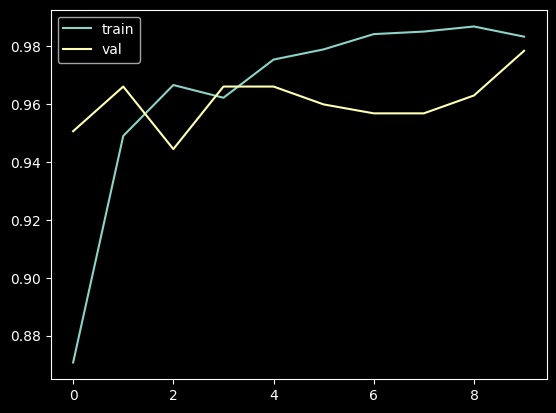

In [5]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.legend()
plt.show()

In [17]:
import cv2
import numpy as np

img = cv2.imread("globosTest1.jpg")
img = cv2.resize(img, IMG_SIZE)
img = img / 255.0
img = np.expand_dims(img, axis=0)

pred = model.predict(img)
class_idx = np.argmax(pred)
class_name = list(train_data.class_indices.keys())[class_idx]

print("Predict: ", class_name)
print(train_data.class_indices[class_name])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Predict:  bird
2
